<a name="projet-7"></a>
# PROJET 7 : Loan Default Prediction #

<a name="contenu"></a>
## Contenu Partie N°1 ##
- Objectifs
- Import des données
- CSV en Parquet
- Etude des colonnes "loan status" et "issue_d"


<a name="objectifs"></a>
## Objectifs ##

_**Contexte :**_
- Les institutions financières doivent évaluer le risque de défaut de paiement des prêts.
- Des prédictions précises peuvent aider à prendre des décisions de prêt.
- Le Machine learning peut analyser l'historique des données afin de prédire les défauts.

_**Objectifs :**_
- Construire un modèle prédictif de défaut de paiement basé sur le profil des emprunteurs.
- Identifier les variables clés qui influent le plus sur le risque de défaut.
- Fournir des recommendations pour atténuer les risques.

_**Origine des données :**_
Le dataset utilisé provient de la plateforme Kaggle et regroupe l'historique complet des prêts acceptés par LendingClub entre 2007 et 2018. 
* **Volume :** Plus de 2,2 millions d'observations.
* **Richesse :** 151 variables décrivant le profil financier (revenus, dettes, historique de crédit) et les conditions du prêt (taux, mensualités).

- "All Lending Club loan data" (2007 through current Lending Club accepted and rejected loan data)
- URL : https://www.kaggle.com/datasets/wordsforthewise/lending-club/data

_**Qu'est-ce que LendingClub ?**_

**LendingClub** est une plateforme américaine de prêt entre particuliers (Peer-to-Peer Lending), fondée en 2006. Contrairement à une banque classique, elle agit comme un intermédiaire technologique :

* **Le concept :** Elle permet à des particuliers ou à des investisseurs institutionnels de prêter de l'argent directement à d'autres particuliers via une plateforme en ligne.

_**Défis :**_
- Traitement des classes déséquilibrées: gérer les jeux de données où les cas de défaut son minoritaires.
- Feature engineering: extraire les indicateurs les plus pertinents du profil des candidats.
- Interprétabilité du modèle: transformer les résultats techniques enleviers d'action concrets.


In [1]:
import gc
# import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
# import os
import pandas as pd
# import plotly.express as px
# import scipy.stats as sps
import seaborn as sns

<a name="import"></a>
## Import des données ##


In [2]:
df = pd.read_csv("DATA/accepted_2007_to_2018Q4.csv", engine='pyarrow')

# df = pd.read_csv("DATA/accepted_2007_to_2018Q4.csv",low_memory=False) 
# "low_memory=False" nécessite un temps de traitement bien supérieur.

In [3]:
# Correction du format de 'id'

df['id'] = df['id'].astype(str)

In [4]:
# Conversion de la colonne issue_d en format datetime

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')

<a name="csv-en-parquet"></a>
## CSV en Parquet ## 


Le passage au format **Apache Parquet** est une étape importante pour ce projet :
* **Vitesse :** Lecture jusqu'à 10x plus rapide qu'un CSV.
* **Mémoire :** Compression drastique des données (passage de Go à Mo).
* **Fiabilité :** Conservation native des types de colonnes (dates, nombres), évitant les erreurs de typage lors des chargements futurs.

In [5]:
# Sauvegarder en parquet

df.to_parquet("DATA/accepted_2007_to_2018Q4.parquet")

print("Conversion terminée !")

Conversion terminée !


In [6]:
# Nettoyer la mémoire vive (RAM)

# Suppression du DataFrame chargé depuis le CSV
if 'df' in locals():
    del df

# Libération de la mémoire
gc.collect()

# Chargement du fichier Parquet (beaucoup plus léger)
df = pd.read_parquet("DATA/accepted_2007_to_2018Q4.parquet")

print("Données chargées depuis le format Parquet !")
print(f"Dimensions du dataset : {df.shape}")

Données chargées depuis le format Parquet !
Dimensions du dataset : (2260701, 151)


Notre base de données contient 2260701 lignes et 151 colonnes 

In [7]:
df

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: datetime64[us](1), float64(113), str(37)
memory usage: 3.0 GB


In [9]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,dti,delinq_2yrs,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2260668,2.258957e+06,2.260639e+06,...,10917.0,10917.000000,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,2016-05-02 18:48:08.652734,1.882420e+01,3.068792e-01,...,3.0,155.045981,3.0,13.743886,454.798089,11636.883942,193.994321,5010.664267,47.780365,13.191322
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,2007-06-01 00:00:00,-1.000000e+00,0.000000e+00,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,2015-04-01 00:00:00,1.189000e+01,0.000000e+00,...,3.0,59.440000,3.0,5.000000,175.230000,5627.000000,44.440000,2208.000000,45.000000,6.000000
50%,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,2016-07-01 00:00:00,1.784000e+01,0.000000e+00,...,3.0,119.140000,3.0,15.000000,352.770000,10028.390000,133.160000,4146.110000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2017-11-01 00:00:00,2.449000e+01,0.000000e+00,...,3.0,213.260000,3.0,22.000000,620.175000,16151.890000,284.190000,6850.172500,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,2018-12-01 00:00:00,9.990000e+02,5.800000e+01,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000
std,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,2.671735e+02,1.126962e+05,NaN,1.418333e+01,8.672303e-01,...,0.0,129.040594,0.0,9.671178,375.385500,7625.988281,198.629496,3693.122590,7.311822,8.159980


In [10]:
## Déterminons le nombre de valeurs manquantes par colonnes
df.isnull().sum()

id                             0
member_id                2260701
loan_amnt                     33
funded_amnt                   33
funded_amnt_inv               33
                          ...   
settlement_status        2226455
settlement_date          2226455
settlement_amount        2226455
settlement_percentage    2226455
settlement_term          2226455
Length: 151, dtype: int64

In [11]:
## pourcentage de valeurs manquantes par colonne
(df.isnull().mean()*100)

id                         0.00000
member_id                100.00000
loan_amnt                  0.00146
funded_amnt                0.00146
funded_amnt_inv            0.00146
                           ...    
settlement_status         98.48516
settlement_date           98.48516
settlement_amount         98.48516
settlement_percentage     98.48516
settlement_term           98.48516
Length: 151, dtype: float64

On remarque qu'il y'a des variables qui ont de grands nombres de valeurs manquantes.

In [12]:
## les variables ayant plus de 80% de valeurs manquantes
missing_values_percentage= df.isna().mean()[df.isna().mean() >= 0.8]

In [13]:
missing_values_percentage

member_id                                     1.000000
desc                                          0.944236
mths_since_last_record                        0.841131
annual_inc_joint                              0.946605
dti_joint                                     0.946607
verification_status_joint                     0.948808
revol_bal_joint                               0.952218
sec_app_fico_range_low                        0.952218
sec_app_fico_range_high                       0.952218
sec_app_earliest_cr_line                      0.952218
sec_app_inq_last_6mths                        0.952218
sec_app_mort_acc                              0.952218
sec_app_open_acc                              0.952218
sec_app_revol_util                            0.953030
sec_app_open_act_il                           0.952218
sec_app_num_rev_accts                         0.952218
sec_app_chargeoff_within_12_mths              0.952218
sec_app_collections_12_mths_ex_med            0.952218
sec_app_mt

On remarque qu'il y'a des colonnes qui n'ont pratiquement pas de valeurs.

In [14]:
missing_values_percentage.count()

np.int64(39)

Il y a 39 variables qui ont plus de 80% de valeurs manquantes.


In [15]:
## L'état des prêts.
stats_pret = pd.concat([df['loan_status'].value_counts(), 
                df['loan_status'].value_counts(normalize=True) * 100], 
               axis=1, keys=['Nombre', 'Pourcentage (%)'])

print(stats_pret)

                                                     Nombre  Pourcentage (%)
loan_status                                                                 
Fully Paid                                          1076751        47.629771
Current                                              878317        38.852100
Charged Off                                          268559        11.879630
Late (31-120 days)                                    21467         0.949587
In Grace Period                                        8436         0.373164
Late (16-30 days)                                      4349         0.192377
Does not meet the credit policy. Status:Fully Paid     1988         0.087939
Does not meet the credit policy. Status:Charged...      761         0.033663
Default                                                  40         0.001769


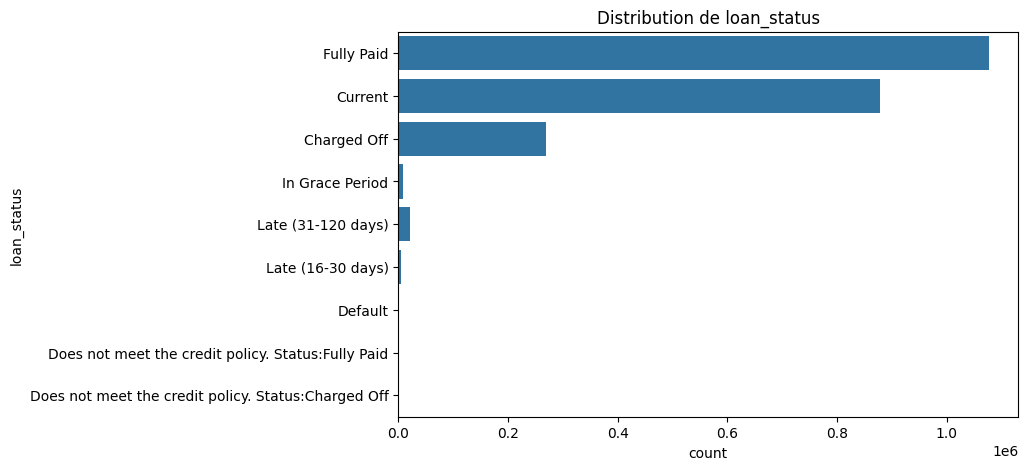

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(y='loan_status', data=df)
plt.title("Distribution de loan_status")
plt.show()

Nous avons un bon apperçu des prêts déjà remboursés, de ceux en cours (qui n'ont fait l'objet d'aucun retard) ainsi que la part des prêts qui ont fait défaut.

In [17]:
num_vars = df.select_dtypes(include=['int64','float64']).columns
cat_vars = df.select_dtypes(include=['object', 'str']).columns

print("Variables numériques :", len(num_vars))
print("Variables catégorielles :", len(cat_vars))


Variables numériques : 113
Variables catégorielles : 37


La base contient 113 variables numériques et 37 variables catégorielles.

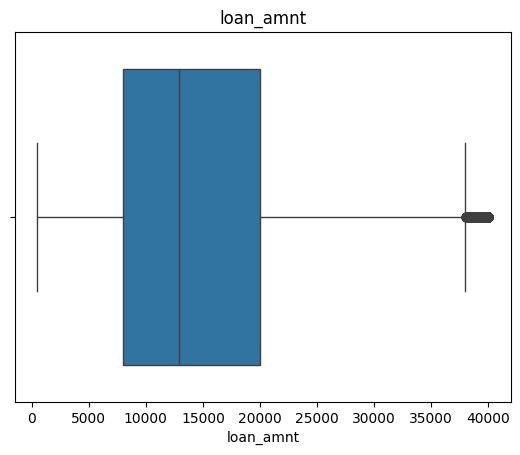

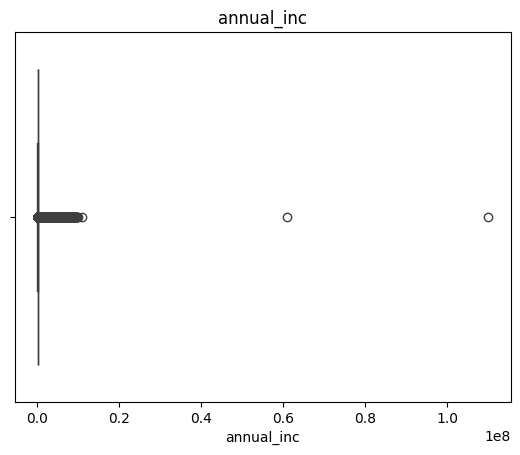

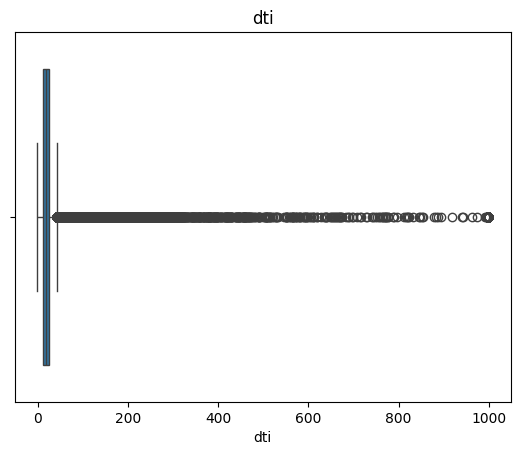

In [18]:
for col in ['loan_amnt','annual_inc','dti']:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

<a name="etude-loan-status-et-issue-d"></a>
## Etude des colonnes "loan status" et "issue_d" ## 


In [19]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [20]:
# Filtre pour ne garder que les lignes "Current"
current_loans = df[df['loan_status'] == 'Current']

# Calcule des occurrences de issue_d sur ce sous-ensemble
counts = current_loans['issue_d'].value_counts().sort_index(ascending=False)

print("Aperçu des occurrences :")
print(counts)

Aperçu des occurrences :
issue_d
2018-12-01    38540
2018-11-01    39779
2018-10-01    43357
2018-09-01    35806
2018-08-01    41548
              ...  
2014-03-01      283
2014-02-01       44
2014-01-01        5
2013-12-01        4
2013-10-01        2
Name: count, Length: 62, dtype: int64


In [21]:
# Séparation en deux groupes en utilisant une simple comparaison de chaînes de caractères
mask_recent = counts.index >= '2017-01'
mask_old = counts.index <= '2016-12'

# Calcule de la somme pour chaque groupe
count_2017_2018 = counts[mask_recent].sum()
count_2016_and_before = counts[mask_old].sum()

print(f"Occurrences de 'Current' (2017-01 à 2018-12) : {count_2017_2018}")
print(f"Occurrences de 'Current' (2016-12 et inférieur) : {count_2016_and_before}")

Occurrences de 'Current' (2017-01 à 2018-12) : 689032
Occurrences de 'Current' (2016-12 et inférieur) : 189285


In [22]:
# Retrait des "current" (récents comme anciens)
lignes_a_supprimer = (df['loan_status'] == 'Current') # & (df['issue_d'] >= '2017-01-01')

# On met à jour le dataframe
df = df[~lignes_a_supprimer].copy()

# Vérification
print(f"Nombre de lignes restantes dans le dataframe après nettoyage : {len(df)}")

Nombre de lignes restantes dans le dataframe après nettoyage : 1382384


In [23]:
# Sauvegardes en vue de la partie suivante

# Données

df.to_parquet("DATA/accepted_2007_to_2018Q4_filtered.parquet")
print("Fichier préparé pour l'étape suivante.")

Fichier préparé pour l'étape suivante.


In [24]:
# 1. Liste des variables et DataFrames à supprimer de la Partie A
a_purger = [
    'df', 'missing_values_percentage', 'stats_pret', 'num_vars', 'cat_vars',
    'current_loans', 'counts', 'mask_recent', 'mask_old', 
    'count_2017_2018', 'count_2016_and_before', 'lignes_a_supprimer'
]

# 2. Suppression de l'environnement 
for var in a_purger:
    if var in locals():
        del locals()[var]

# 3. Libération de la mémoire
gc.collect()

print("🧹 Mémoire purgée avec succès ! Cette partie est terminée et le notebook est prêt à être fermé.")

🧹 Mémoire purgée avec succès ! Cette partie est terminée et le notebook est prêt à être fermé.


----
